In [3]:
# Gneral Imports

import os
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import torch 
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import cv2
import nibabel as nb
import shutil


%matplotlib inline

In [15]:
directory = Path("/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All" )
res = (len(list(directory.glob("AV45/3.0/*.png"))))
print(res)

420


In [66]:
PIB_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All/PIB"

if os.path.exists(PIB_folder):
    print("Folder already existed")
else:
    os.makedirs(PIB_folder)
    print("Folder created.")

class_names = [0.0, 0.5, 1.0, 2.0, 3.0]

for name in class_names:
    temp_folder_name = PIB_folder + "/" + str(name)
    if os.path.exists(temp_folder_name):
        pass
    else:
        os.makedirs(temp_folder_name)
        print("{} folder created.".format(name))

Folder created.
0.0 folder created.
0.5 folder created.
1.0 folder created.
2.0 folder created.
3.0 folder created.


In [75]:
temp_PIB_folder = "/Volumes/Hard Drive Mac/temp_nifti_pib"
if os.path.exists(temp_PIB_folder):
    print("Folder already existed")
else:
    os.makedirs(temp_PIB_folder)
    print("Folder created.")

Folder created.


In [86]:
folder_names = ['Owoeyeb-20230524_085440', 'Owoeyeb-20230524_114753', 'Owoeyeb-20230527_223750', 'Owoeyeb-20230528_205505', 'Owoeyeb-20230528_224534']

base_folder = "/Volumes/Hard Drive Mac"
os.chdir(base_folder)
# print(os.getcwd())
files = (os.listdir())
# print((files))


for i in folder_names:
    folder = base_folder + "/" + i + "/"
    print(folder)
    os.chdir(folder)
    temp = ((os.listdir((folder))))
    for each in temp:
        if each == ".DS_Store":
            pass
        else:
            folder_name = f"{folder}/{each}/pet1/NIFTI/"
            fn = (os.listdir(folder_name))[0]
            previous_file = (f"{folder_name}{fn}")
            new_file_dir = f"{temp_PIB_folder}/{fn}"
            print(previous_file)
            print(new_file_dir)
            shutil.move(previous_file, new_file_dir)
            print("done")
            

/Volumes/Hard Drive Mac/Owoeyeb-20230524_085440/
/Volumes/Hard Drive Mac/Owoeyeb-20230524_085440//OAS30052_PIB_d1268/pet1/NIFTI/sub-OAS30052_ses-d1268_acq-PIB_pet.nii.gz
/Volumes/Hard Drive Mac/temp_nifti_pib/sub-OAS30052_ses-d1268_acq-PIB_pet.nii.gz
done
/Volumes/Hard Drive Mac/Owoeyeb-20230524_085440//OAS30052_PIB_d2723/pet1/NIFTI/sub-OAS30052_ses-d2723_acq-PIB_pet.nii.gz
/Volumes/Hard Drive Mac/temp_nifti_pib/sub-OAS30052_ses-d2723_acq-PIB_pet.nii.gz
done
/Volumes/Hard Drive Mac/Owoeyeb-20230524_085440//OAS30053_PIB_d0561/pet1/NIFTI/sub-OAS30053_ses-d0561_acq-PIB_pet.nii.gz
/Volumes/Hard Drive Mac/temp_nifti_pib/sub-OAS30053_ses-d0561_acq-PIB_pet.nii.gz
done
/Volumes/Hard Drive Mac/Owoeyeb-20230524_085440//OAS30053_PIB_d1471/pet1/NIFTI/sub-OAS30053_ses-d1471_acq-PIB_pet.nii.gz
/Volumes/Hard Drive Mac/temp_nifti_pib/sub-OAS30053_ses-d1471_acq-PIB_pet.nii.gz
done
/Volumes/Hard Drive Mac/Owoeyeb-20230524_085440//OAS30058_PIB_d0836/pet1/NIFTI/sub-OAS30058_ses-d0836_acq-PIB_pet.nii.gz
/V

1068
1 sub-OAS30001_ses-d0423_acq-PIB_pet.nii.gz
(128, 128, 63, 51)
2 sub-OAS30001_ses-d0847_acq-PIB_pet.nii.gz
(128, 128, 63, 25)
3 sub-OAS30001_ses-d1317_acq-PIB_pet.nii.gz
(128, 128, 63, 24)
4 sub-OAS30001_ses-d2438_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
5 sub-OAS30001_ses-d3132_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
6 sub-OAS30001_ses-d4467_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
7 sub-OAS30002_ses-d0371_acq-PIB_pet.nii.gz
(128, 128, 63, 52)
8 sub-OAS30002_ses-d0975_acq-PIB_pet.nii.gz
(128, 128, 63, 25)
9 sub-OAS30002_ses-d2345_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
10 sub-OAS30003_ses-d2669_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
11 sub-OAS30003_ses-d4954_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
12 sub-OAS30003_ses-d756_acq-PIB_pet.nii.gz
(128, 128, 63, 52)
13 sub-OAS30004_ses-d1104_acq-PIB_pet.nii.gz
(128, 128, 63, 25)
14 sub-OAS30004_ses-d2229_acq-PIB_pet.nii.gz
(128, 128, 109, 26)
15 sub-OAS30004_ses-d4700_acq-PIB_pet.nii.gz
(128, 128, 109, 6)
16 sub-OAS30005_ses-d1306_acq-PIB_pet.

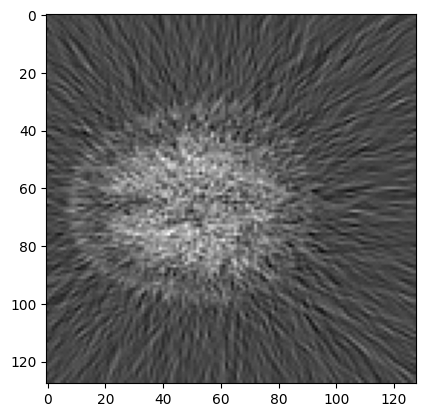

In [287]:
# print(len(os.listdir("/Volumes/Hard Drive Mac/temp_nifti_pib")))
base_folder = "/Volumes/Hard Drive Mac/temp_nifti_pib"
os.chdir(base_folder)
pib_nifti = os.listdir(base_folder)
print(len(pib_nifti))
n = 0
ls = []
firsta = []
seconda = []
thirda = [159, 74, 109, 88, 63, 127]
fourtha = [3, 6, 17, 20, 23, 24, 25, 26, 34, 41, 45, 48, 49, 50, 51, 52, 53]
done_list = []
skipped_list = []
start = 0
end = 1067
for i in range(start, end):
    temp_img = []
    pib = pib_nifti[i]
    # pib = "sub-OAS31151_ses-d392_acq-PIB_pet.nii.gz"
    if pib == ".DS_Store" or pib in done_list or pib in skipped_list:
        pass
    else:
        tensor_nifti = nb.load(pib) # The pics is extracted but remains in a nibabel object
        temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
        print(i, pib)
        print(temp_arr.shape)
        
        if len(temp_arr.shape) < 4:
            pass
        elif temp_arr.shape[3] == 45:
            print(temp_arr.shape, pib)
            img = temp_arr[:, :, 25, 40]
            plt.imshow(img, cmap=plt.cm.gray)
        
            break


# print(set(firsta))
# print(set(seconda))
# print(set(thirda))
# print(set(fourtha))

# 53: 21 - 36 ,35 - 39
# 52: 21 - 36 ,35 - 39
# 51: 28 - 39 ,35 - 39
# 50: 25 - 36 ,42 - 45
# 49: 26 - 35 ,40 - 41
# 48: 25 - 30 ,40 - 42
# 45: "sub-OAS31151_ses-d392_acq-PIB_pet.nii.gz"
# 41: "bad for human visuals"
# 34: "let go"
# 26: 50 - 60, 16-17
# 25: 18 - 35, 12 - 15
# 24: 24 - 30, 11 - 15
# 23: "Too bright"
# 20: Too noisy
# 17: Too noisy
# 6: Poor rendering could not see
# 3: Poor







#2592
# {6, 41, 49, 50, 51, 52, 53, 24, 25, 26}
# {159, 74, 109, 88, 63, 127}


5152.930519834932 77639.6484375 -35996.36328125


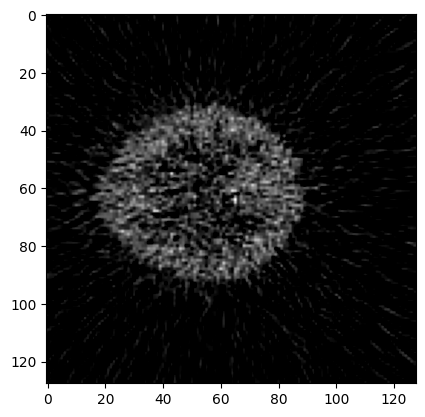

In [257]:
vmin = img.copy().min()
vmax = img.copy().max()
vmean = img.copy().mean()
print(vmean, vmax, vmin)
plt.imshow((img.copy()), cmap="gray", vmin=vmean, vmax=vmax)

-30240.87109375


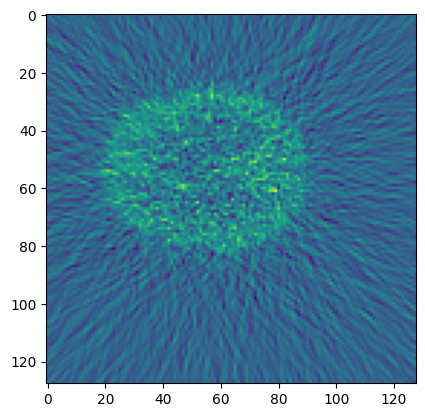

In [224]:
plt.imshow(img)
print(img.copy().min())

In [58]:
os.getcwd()

'/Volumes/Hard Drive Mac/temp_nifti_pib'

In [4]:




base_folder = "/Volumes/Hard Drive Mac/temp_nifti_pib"
processed_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All/PIB"
adrc_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Spreadsheet/ADRC Clinical Data.csv"
os.chdir(base_folder)

pib_nifti = os.listdir(base_folder)
print(len(pib_nifti))
n = 0
done_list = []
skipped_list = []
except_list = [45, 34, 41, 23, 20, 17, 6, 3]
accept_list = [53, 52, 51, 50, 49, 48, 26, 25, 24]
start = 950
end = 1069
starts_ends = {
53: "21_36-35_39",
52: "21_36-35_39",
51: "28_39-35_39",
50: "25_36-42_45",
49: "26_35-40_41",
48: "25_30-40_42",
26: "50_60-16_17",
25: "18_35-12_15",
24: "24_30-11_15"
}








for i in range(start, end):
    pib = pib_nifti[i]
    if pib == ".DS_Store" or pib in done_list or pib in skipped_list:
        pass
    else:
        tensor_nifti = nb.load(pib) # The pics is extracted but remains in a nibabel object
        temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
        print(i, temp_arr.shape)
        if len(temp_arr.shape) != 4 or temp_arr.shape[3] in except_list:
            
            skipped_list.append(pib)
            print("passed")
            pass
        else:
            try:
                time_frame = temp_arr.shape[3]
                subject_id = pib.split("-")[1].split("_")[0]
                assessement_id = pib.split("-")[2].split("_")[0]
                typ = pib.split("-")[-1].split("_")[0]
                raw_df = pd.read_csv(adrc_folder)
                cdr = max(raw_df[raw_df["Subject"] == subject_id]["cdr"])
                new_file_name = "{}_{}_{}".format(subject_id, typ, cdr)
                if time_frame in accept_list:
                    
                    brain_lenght_start = int(starts_ends[time_frame].split("_")[0])
                    brain_lenght_end = int(starts_ends[time_frame].split("_")[1].split("-")[0])
                    brain_time_frame_start = int(starts_ends[time_frame].split("-")[1].split("_")[0])
                    brain_time_frame_end = int(starts_ends[time_frame].split("-")[1].split("_")[1])
                for time in range(brain_time_frame_start, brain_time_frame_end + 1):
                    for lenght in range(brain_lenght_start, brain_lenght_end + 1):
                        temp = temp_arr[:, :, lenght, time]
                        new_file_name = "{}_{}_{}_{}_{}".format(subject_id, typ, cdr, lenght, time)
                        temp_folder = (processed_folder + "/" + str(cdr) + "/" + new_file_name + ".png")
                        plt.imsave(temp_folder, temp)
                        print("{} has been processed".format(pib))
                        n += 1
                done_list.append(pib)
            except Exception as err:
                print("Went into exception and added to skipped list")
                print()
                print(err)
                skipped_list.append(pib)
                pass
    
                
print("{} images saved and classified by cdr".format(n))

print(skipped_list)


print(done_list)

1068
950 (440, 440, 159, 26)
Went into exception and added to skipped list
951 (440, 440, 159, 26)
Went into exception and added to skipped list
952 (128, 128, 109, 26)
Went into exception and added to skipped list
953 (440, 440, 159, 26)
Went into exception and added to skipped list
954 (440, 440, 159, 26)
Went into exception and added to skipped list
955 (128, 128, 109, 6)
passed
956 (128, 128, 109, 26)
Went into exception and added to skipped list
957 (128, 128, 109, 26)
Went into exception and added to skipped list
958 (128, 128, 109, 26)
Went into exception and added to skipped list
959 (440, 440, 88, 6)
passed
960 (128, 128, 109, 26)
Went into exception and added to skipped list
961 (440, 440, 88, 26)
Went into exception and added to skipped list
962 (128, 128, 109, 26)
Went into exception and added to skipped list
963 (440, 440, 88, 26)
Went into exception and added to skipped list
964 (440, 440, 159, 26)
Went into exception and added to skipped list
965 (440, 440, 159, 26)
Went

OSError: [Errno 6] Device not configured

In [302]:


# starts_ends = {
# 53: "21_36-35_39",
# 52: "21_36-35_39",
# 51: "28_39-35_39",
# 50: "25_36-42_45",
# 49: "26_35-40_41",
# 48: "25_30-40_42",
# 26: "50_60-16_17",
# 25: "18_35-12_15",
# 24: "24_30-11_15"
# }
# time_frame = 51
# brain_lenght_start = int(starts_ends[time_frame].split("_")[0])
# brain_lenght_end = int(starts_ends[time_frame].split("_")[1].split("-")[0])
# brain_time_frame_start = int(starts_ends[time_frame].split("-")[1].split("_")[0])
# brain_time_frame_end = int(starts_ends[time_frame].split("-")[1].split("_")[1])


# print(brain_lenght_start + brain_lenght_end + brain_time_frame_start + brain_time_frame_end)


for i in range(0, 2):
    print(i)

0
1


In [95]:
import numpy as np, cv2
from matplotlib import pyplot as plt

img = cv2.cvtColor(use.copy(), cv2.COLOR_BGR2RGB)
dst = cv2.fastNlMeansDenoisingColored(img, None, 20, 20, 14, 42)
cv2.imwrite('birds_out.png', cv2.cvtColor(dst, cv2.COLOR_RGB2BGR))
plt.subplot(121); plt.imshow(img)
plt.subplot(122); plt.imshow(dst)
plt.show()


error: OpenCV(4.7.0) /Users/xperience/GHA-OCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.simd_helpers.hpp:94: error: (-2:Unspecified error) in function 'cv::impl::(anonymous namespace)::CvtHelper<cv::impl::(anonymous namespace)::Set<1, -1, -1>, cv::impl::(anonymous namespace)::Set<3, 4, -1>, cv::impl::(anonymous namespace)::Set<0, 2, 5>, cv::impl::(anonymous namespace)::NONE>::CvtHelper(cv::InputArray, cv::OutputArray, int) [VScn = cv::impl::(anonymous namespace)::Set<1, -1, -1>, VDcn = cv::impl::(anonymous namespace)::Set<3, 4, -1>, VDepth = cv::impl::(anonymous namespace)::Set<0, 2, 5>, sizePolicy = cv::impl::(anonymous namespace)::NONE]'
> Unsupported depth of input image:
>     'VDepth::contains(depth)'
> where
>     'depth' is 6 (CV_64F)


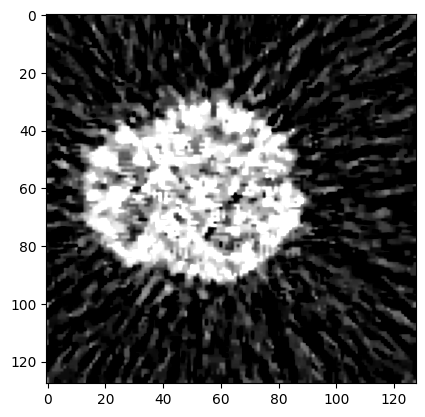

In [ ]:
from scipy import ndimage

med_denoised = ndimage.median_filter(img.copy(), 3)
plt.imshow(med_denoised, cmap=plt.cm.gray, vmin=-500, vmax=36000)

In [89]:
use = img

In [180]:
print(img.min())
print(img.max())

-64569.9453125
125227.7421875
